In [1]:
import pandas as pd

df = pd.read_csv("HR-Employee-Attrition.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


Loading the dataset and checking the first 5 rows

In [2]:
map = {
    'Age': 'age',
    'Education': 'education_level',
    'TotalWorkingYears': 'years_of_experience',
    'HourlyRate': 'technical_test_score',
    'PerformanceRating': 'interview_score',
    'Attrition': 'suitable_for_employment',
    'NumCompaniesWorked': 'previous_employment'
    }

new_df = df[['Age', 'Education', 'TotalWorkingYears', 'HourlyRate', 'PerformanceRating', 'Attrition', 'NumCompaniesWorked']].copy()
new_df.rename(columns=map, inplace=True)
new_df['suitable_for_employment'] = new_df['suitable_for_employment'].apply(lambda x: 'Yes' if x == 'No' else 'No')
new_df['previous_employment'] = pd.to_numeric(new_df['previous_employment'])


new_df.head()

,age,education_level,years_of_experience,technical_test_score,interview_score,suitable_for_employment,previous_employment
0,41,2,8,94,3,No,8
1,49,1,10,61,4,Yes,1
2,37,2,7,92,3,No,6
3,33,4,8,56,3,Yes,1
4,27,1,6,40,3,Yes,9


Mapping values like TotalWorkingYears to years_of_experience  
Why?  
Since the dataset provided lacks some of the requested values


In [3]:
new_df['previous_employment'] = new_df['previous_employment'].apply(lambda x: 'Yes' if x > 0 else 'No')

new_df.head()

,age,education_level,years_of_experience,technical_test_score,interview_score,suitable_for_employment,previous_employment
0,41,2,8,94,3,No,Yes
1,49,1,10,61,4,Yes,Yes
2,37,2,7,92,3,No,Yes
3,33,4,8,56,3,Yes,Yes
4,27,1,6,40,3,Yes,Yes


Checks the first 5 rows of the new_df data frame

# Basic EDA

In [4]:
new_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   age                      1470 non-null   int64
 1   education_level          1470 non-null   int64
 2   years_of_experience      1470 non-null   int64
 3   technical_test_score     1470 non-null   int64
 4   interview_score          1470 non-null   int64
 5   suitable_for_employment  1470 non-null   str  
 6   previous_employment      1470 non-null   str  
dtypes: int64(5), str(2)
memory usage: 80.5 KB


Gets the overview of the data  
that is:  
- [ ] Columns index
- [ ] Null count
- [ ] Datatype
- [ ] Range index

In [5]:
new_df.describe()

,age,education_level,years_of_experience,technical_test_score,interview_score
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,2.912925,11.279592,65.891156,3.153741
std,9.135373,1.024165,7.780782,20.329428,0.360824
min,18.000000,1.000000,0.000000,30.000000,3.000000
25%,30.000000,2.000000,6.000000,48.000000,3.000000
50%,36.000000,3.000000,10.000000,66.000000,3.000000
75%,43.000000,4.000000,15.000000,83.750000,3.000000
max,60.000000,5.000000,40.000000,100.000000,4.000000


Shows the statistics of the numerical values
mean, standard deviation and the rest

Text(0.5, 1.0, 'Age Distribution')

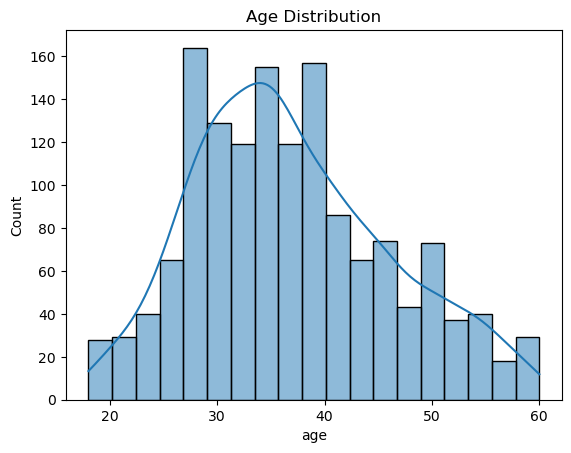

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.subplot(1, 1, 1)
sns.histplot(new_df['age'], kde=True)
plt.title('Age Distribution')

This shows that the tree is likely to split at age <= 35  
Since there's a high concentration of people at around the age of 35

Text(0.5, 1.0, 'Technical Test Score Distribution')

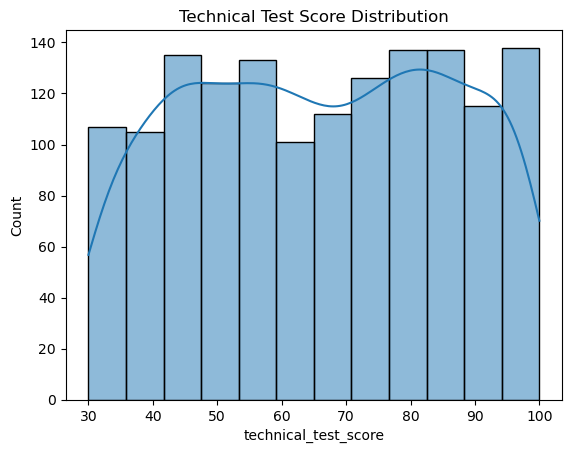

In [7]:
plt.subplot(1, 1, 1)
sns.histplot(new_df['technical_test_score'], kde=True)
plt.title("Technical Test Score Distribution")

This shows an even spread  
meaning that the tree will split at almost anywhere

Text(0.5, 1.0, 'Years of Experience Distribution')

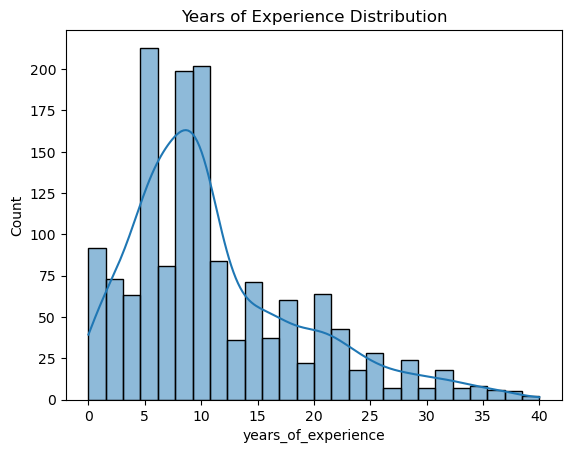

In [8]:
plt.subplot(1, 1, 1)
sns.histplot(new_df['years_of_experience'], kde=True)
plt.title("Years of Experience Distribution")

The interest area is at years_of_experience < 10 

Text(0.5, 1.0, 'Previous Employment History')

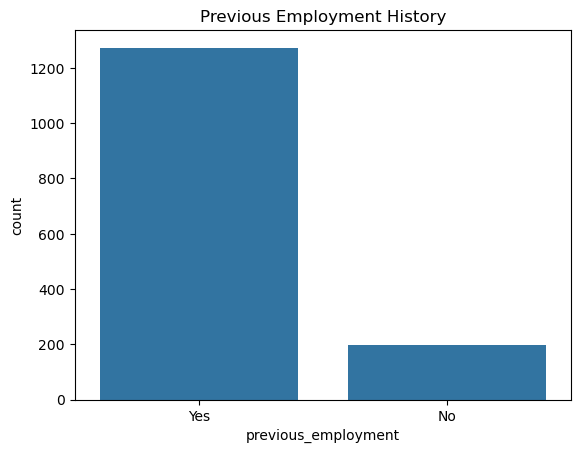

In [9]:
plt.subplot(1, 1, 1)
sns.countplot(x='previous_employment', data=new_df)
plt.title("Previous Employment History")

There's an imbalance meaning that a lazy tree will most likely default to yes

Text(0.5, 1.0, 'Suitable For Employment Count')

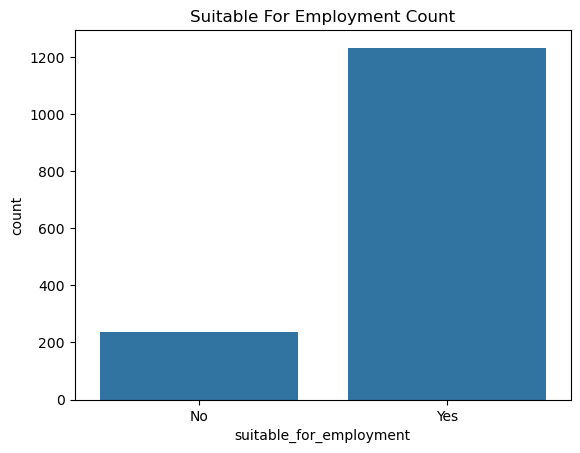

In [10]:
plt.subplot(1, 1, 1)
sns.countplot(x='suitable_for_employment', data=new_df)
plt.title('Suitable For Employment Count')


This shows that there is an imbalance in the target variable,
this means that if the decision tree is lazy it will predict yes for everything

# Data Prepocessing

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

new_df['previous_employment'] = le.fit_transform(new_df['previous_employment'])
new_df['suitable_for_employment'] = le.fit_transform(new_df['suitable_for_employment'])

#new_df['previous_employment'].unique()
#new_df['suitable_for_employment'].unique()



Converting the yes and no to 1 and 0 

In [12]:
X = new_df.drop('suitable_for_employment', axis=1)
y = new_df['suitable_for_employment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#X_train.head()
#X_test.head()
#y_train.head()
#y_test.head()

Spllitting and the data into features(X) and the target(y)

# Model Building

In [13]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(random_state=42, max_depth=5, class_weight='balanced')

clf.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

The balanced variable ensures that the tree never gets lazy  
It handles the imbalance in the dataset that was previously observed

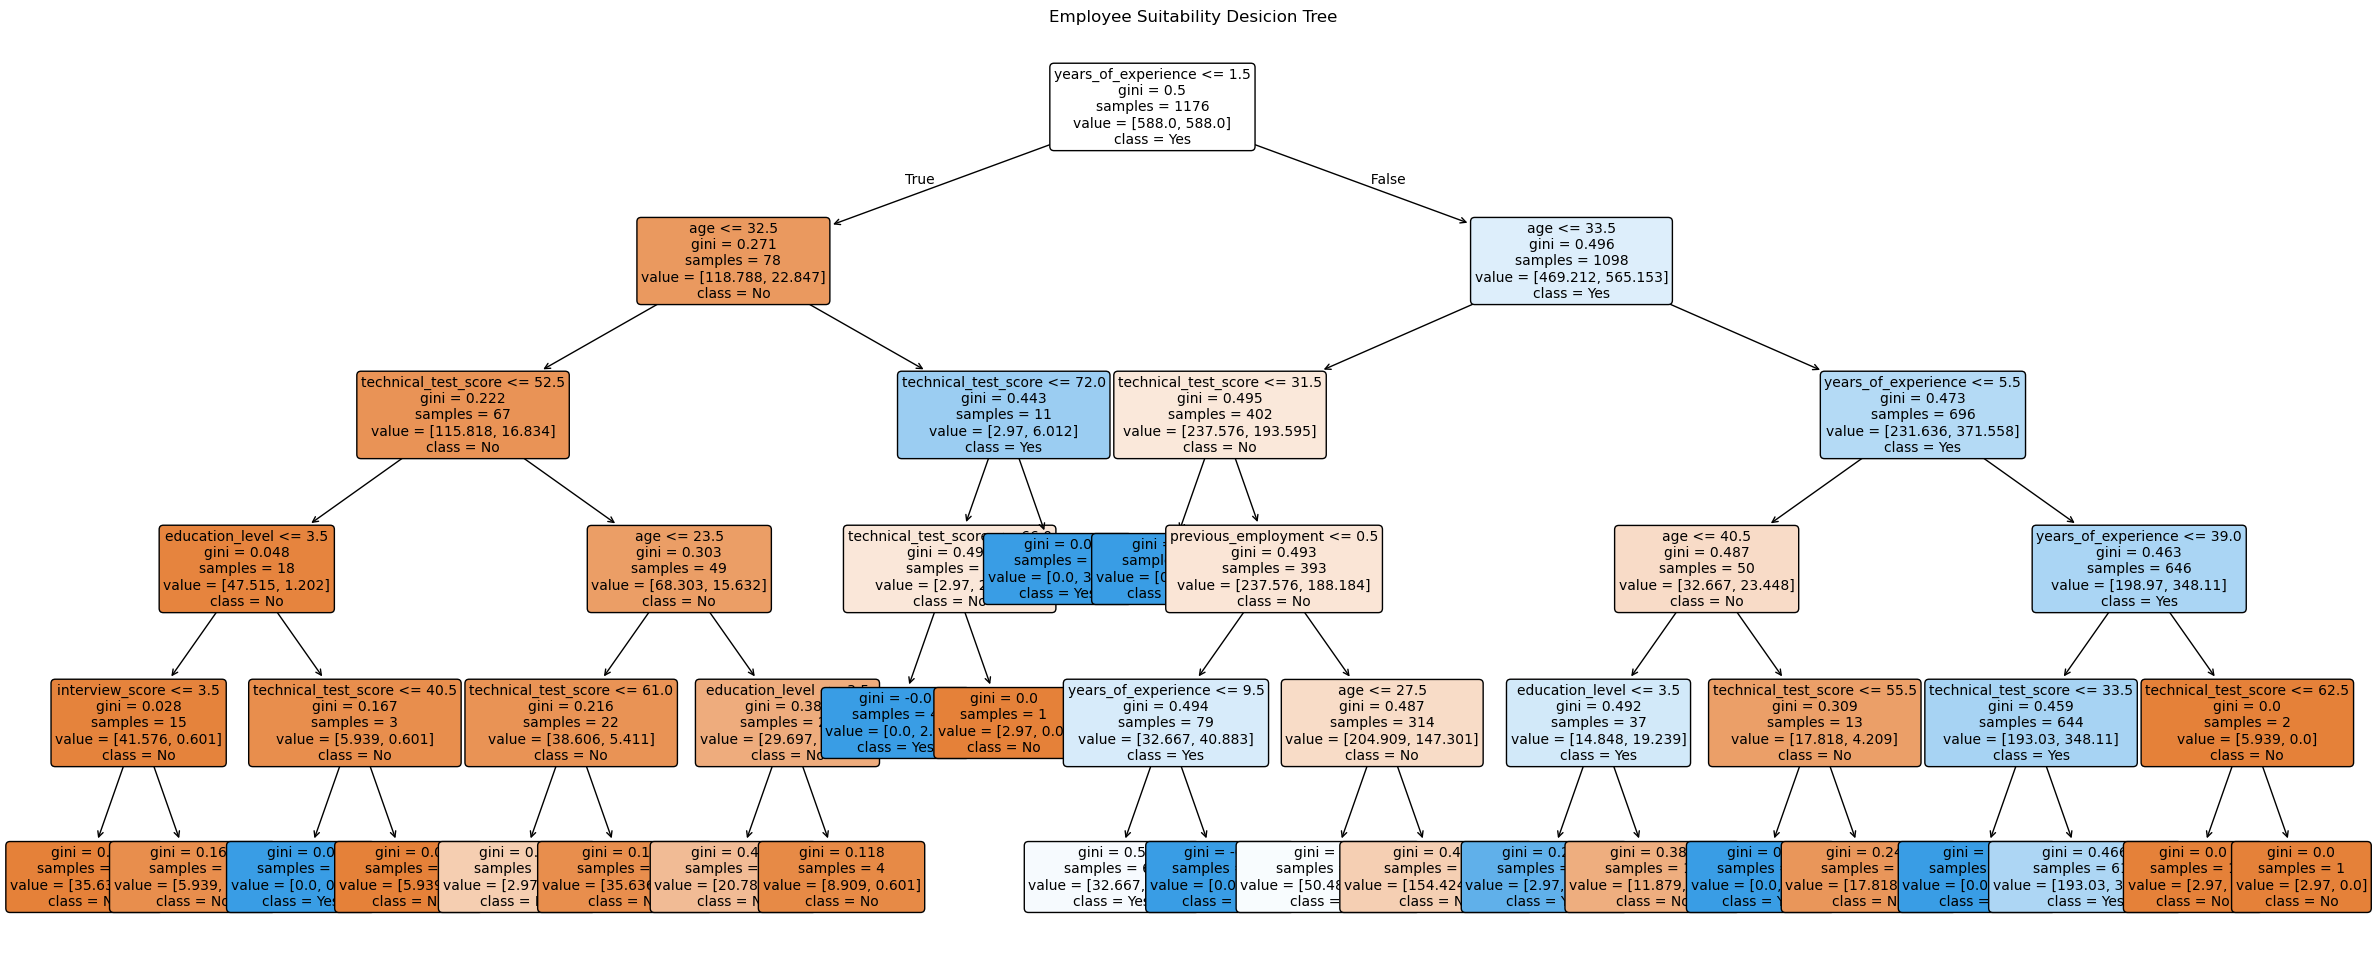

In [14]:
from sklearn.tree import plot_tree

plt.figure(figsize=(30, 12))

plot_tree(clf, 
          feature_names=X.columns,
          class_names=['No', 'Yes'],
          filled=True,
          rounded=True,
          fontsize=10)

plt.title("Employee Suitability Desicion Tree")
plt.show()

### Interpretation  
A Decision tree is a diagram that helps in decision making by visually mapping out different choices and their possible outcomes

This tree is a 


# Testing and Prediction

In [15]:
testing = pd.DataFrame([
    [22, 2, 1, 95, 4, 0],
    [45, 4, 25, 35, 3, 1],
    [31, 3, 8, 70, 3, 1]
], columns=X.columns)

predictions = clf.predict(testing)
probability = clf.predict_proba(testing)

names = ["John Doe", "Jane Doe", "Jack Doe"]

for i, name in enumerate(names):
    status = "Suitable" if predictions[i] == 1 else "Not Suitable"
    confidence = probability[i][predictions[i]] * 100
    print(f"{name}: {status}, branch probability: {confidence}")

John Doe: Not Suitable, branch probability: 90.80779944289694
Jane Doe: Suitable, branch probability: 63.09905266090791
Jack Doe: Not Suitable, branch probability: 61.913805697589595


Creating some dummy test variable and trying to feed the results into the tree



In [16]:
from sklearn.metrics import accuracy_score, confusion_matrix

y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy}")



Accuracy: 0.6972789115646258


The model is about 70% accurate

Text(0.5, 36.72222222222221, 'Predicted')

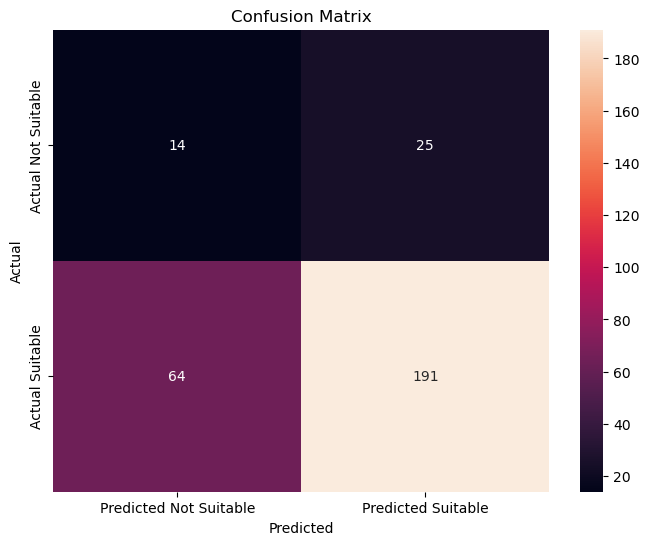

In [17]:
cm = confusion_matrix(y_test, y_pred)


plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', 
            xticklabels=['Predicted Not Suitable', 'Predicted Suitable'],
            yticklabels=['Actual Not Suitable','Actual Suitable'])

plt.title("Confusion Matrix")
plt.ylabel('Actual')
plt.xlabel('Predicted')
